# 11. Modelos CAR — INLA (Intrínseco, BYM) y CARBayes (Leroux)

Implementación de los **tres modelos CAR** de la Sección 3 del libro guía para
clasificación binaria de Altiplanos sobre **celdas de 5 km**:

| Modelo | Motor | Efecto espacial | Descripción |
|---|---|---|---|
| **CAR Intrínseco (ICAR)** | INLA | `model="besag"` | Solo efecto espacial estructurado |
| **BYM** | INLA | `model="bym"` | Estructurado + no estructurado (iid) |
| **Leroux** | CARBayes | `S.CARleroux` | Interpolación entre ICAR e iid via ρ |

**Unidad areal:** celdas de 5 km (2,596 válidas), adyacencia Rook, mismos datos que
el notebook 09 (autorregresivos) y el notebook 11 original (CAR CARBayes).

**Covariables:** altitud, pendiente, relieve (estandarizadas) + dummies de región
(4 zonas del clustering).

Al final se compara con los resultados de los modelos autorregresivos (NB09).

## 1. Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import subprocess, os, sys, time, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)

SEMILLA = 42
np.random.seed(SEMILLA)

BASE = r'C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial'
GPKG_IN = os.path.join(BASE, 'Resultados', 'celdas_car_v2.gpkg')
RES_DIR = os.path.join(BASE, 'Resultados', '11_CAR_INLA_comparacion_v2')
IMG_DIR = os.path.join(BASE, 'Imágenes', '11_CAR_INLA_comparacion_v2')
IO_DIR = os.path.join(BASE, 'Resultados', '11_CAR_INLA_io')
os.makedirs(RES_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(IO_DIR, exist_ok=True)
sys.path.insert(0, os.path.join(BASE, 'Codigo'))

RSCRIPT = r'C:\Program Files\R\R-4.6.1\bin\Rscript.exe'
R_LIBS = r'C:\Users\MSI\AppData\Local\R\win-library\4.6'

print(f'SEMILLA = {SEMILLA}')
print(f'RSCRIPT = {RSCRIPT}')
print(f'R_LIBS = {R_LIBS}')

SEMILLA = 42
RSCRIPT = C:\Program Files\R\R-4.6.1\bin\Rscript.exe
R_LIBS = C:\Users\MSI\AppData\Local\R\win-library\4.6


## 2. Carga de datos y preparación

In [2]:
gdf = gpd.read_file(GPKG_IN).reset_index(drop=True)
print(f'Celdas: {len(gdf)}, Altiplano=1: {int(gdf["y"].sum())} ({gdf["y"].mean()*100:.1f}%)')

region_names = {0: 'C. Central - Magdalena', 1: 'C. Occidental - Farallones',
                2: 'C. Occidental - Atrato', 3: 'C. Central - Altiplanos'}

# Build Rook adjacency from row/col
pos_to_idx = {(int(r['row']), int(r['col'])): i for i, r in gdf.iterrows()}
neighbors = {}
edge_list = []
for i, r in gdf.iterrows():
    ri, ci = int(r['row']), int(r['col'])
    nbrs = []
    for dr, dc in [(0,1), (0,-1), (1,0), (-1,0)]:
        key = (ri + dr, ci + dc)
        if key in pos_to_idx:
            j = pos_to_idx[key]
            nbrs.append(j)
            if j > i:
                edge_list.append((i + 1, j + 1))
    neighbors[i] = nbrs

n_cells = len(gdf)
print(f'Aristas Rook: {len(edge_list)}, grado medio: {2*len(edge_list)/n_cells:.2f}')

# Standardize predictors
scaler = StandardScaler()
topo_cols = ['altitud', 'pendiente', 'relieve']
topo_s = scaler.fit_transform(gdf[topo_cols].values)
gdf['altitud_s'] = topo_s[:, 0]
gdf['pendiente_s'] = topo_s[:, 1]
gdf['relieve_s'] = topo_s[:, 2]

# Region dummies
for reg in [1, 2, 3]:
    gdf[f'region_{reg}'] = (gdf['region'] == reg).astype(int)

print('Datos preparados')

Celdas: 2596, Altiplano=1: 558 (21.5%)
Aristas Rook: 5007, grado medio: 3.86


Datos preparados


## 3. Exportación de datos para R

Se exportan:
- `celdas_inla.csv` — datos de celdas (y, covariables estandarizadas, dummies de región)
- `adj_inla.txt` — archivo de adyacencia en formato INLA (`inla.read.graph`)

In [3]:
# Export cell data
df_export = gdf[['y', 'altitud_s', 'pendiente_s', 'relieve_s',
                 'region_1', 'region_2', 'region_3']].copy()
df_export.index = range(1, len(df_export) + 1)
df_export.index.name = 'id'
csv_path = os.path.join(IO_DIR, 'celdas_inla.csv')
df_export.to_csv(csv_path)
print(f'Celdas exportadas: {csv_path} ({len(df_export)} filas)')

# Export adjacency in INLA graph format
# Format: first line = N, then for each node: node_id, num_neighbors, neighbor_ids...
adj_path = os.path.join(IO_DIR, 'adj_inla.txt')
with open(adj_path, 'w') as f:
    f.write(f'{n_cells}\n')
    for i in range(n_cells):
        nbrs_1based = [j + 1 for j in neighbors[i]]
        f.write(f'{i + 1} {len(nbrs_1based)} {" ".join(map(str, nbrs_1based))}\n')
print(f'Adyacencia exportada: {adj_path}')

# Also export edges for CARBayes (1-indexed)
edges_path = os.path.join(IO_DIR, 'edges_inla.csv')
pd.DataFrame(edge_list, columns=['a', 'b']).to_csv(edges_path, index=False)
print(f'Aristas exportadas: {edges_path} ({len(edge_list)} aristas)')

Celdas exportadas: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_INLA_io\celdas_inla.csv (2596 filas)
Adyacencia exportada: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_INLA_io\adj_inla.txt
Aristas exportadas: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_INLA_io\edges_inla.csv (5007 aristas)


## 4. Script R — INLA (ICAR, BYM) + CARBayes (Leroux)

El script R:
1. Lee los datos y la adyacencia
2. Ajusta 4 modelos:
   - **M0:** GLM no espacial (referencia)
   - **M1:** ICAR (INLA, `model="besag"`)
   - **M2:** BYM (INLA, `model="bym"`)
   - **M3:** Leroux (CARBayes, `S.CARleroux`)
3. Exporta métricas, coeficientes y probabilidades predichas

**Hiperparámetros:**
- INLA: priors por defecto (PC priors para precisión en BYM, log-Gamma en besag).
  `control.compute = list(dic=TRUE, waic=TRUE, config=TRUE)`.
- CARBayes Leroux: `prior.tau2 = c(2, 1)` (IG(2,1) — regularización para evitar
  separación en datos binarios), 13,000 muestras MCMC con 3,000 burn-in.

In [4]:
r_script = r"""
library(INLA)
library(CARBayes)

cat("=== INLA version:", as.character(packageVersion("INLA")), "\\n")
cat("=== CARBayes version:", as.character(packageVersion("CARBayes")), "\\n")

# --- Read data ---
io_dir <- "{IO_DIR_R}"
dat <- read.csv(file.path(io_dir, "celdas_inla.csv"))
N <- nrow(dat)
cat("N =", N, "\\n")
cat("y=1:", sum(dat$y), "(", round(100*mean(dat$y), 1), "%)\\n")

# --- INLA adjacency ---
adj_file <- file.path(io_dir, "adj_inla.txt")
g <- inla.read.graph(adj_file)
cat("Graph loaded:", g$n, "nodes\\n")

dat$id <- 1:N
dat$id2 <- 1:N  # for BYM iid component

# ============================================================
# M0: GLM no espacial (referencia)
# ============================================================
cat("\\n=== M0: GLM no espacial ===\\n")
m0 <- inla(y ~ altitud_s + pendiente_s + relieve_s + region_1 + region_2 + region_3,
           family = "binomial", data = dat, Ntrials = 1,
           control.compute = list(dic = TRUE, waic = TRUE),
           control.predictor = list(compute = TRUE, link = 1))
cat("DIC:", m0$dic$dic, "\\n")
cat("WAIC:", m0$waic$waic, "\\n")
prob_m0 <- m0$summary.fitted.values$mean
cat("AUC:", round(as.numeric(pROC::auc(dat$y, prob_m0)), 4), "\\n")

# ============================================================
# M1: ICAR (CAR Intrínseco via INLA besag)
# ============================================================
cat("\\n=== M1: ICAR (besag) ===\\n")
m1 <- inla(y ~ altitud_s + pendiente_s + relieve_s + region_1 + region_2 + region_3 +
             f(id, model = "besag", graph = g, scale.model = TRUE),
           family = "binomial", data = dat, Ntrials = 1,
           control.compute = list(dic = TRUE, waic = TRUE),
           control.predictor = list(compute = TRUE, link = 1))
cat("DIC:", m1$dic$dic, "\\n")
cat("WAIC:", m1$waic$waic, "\\n")
prob_m1 <- m1$summary.fitted.values$mean
cat("AUC:", round(as.numeric(pROC::auc(dat$y, prob_m1)), 4), "\\n")
cat("Precision (tau) del efecto espacial:", m1$summary.hyperpar[1, "mean"], "\\n")

# ============================================================
# M2: BYM (besag + iid via INLA)
# ============================================================
cat("\\n=== M2: BYM ===\\n")
m2 <- inla(y ~ altitud_s + pendiente_s + relieve_s + region_1 + region_2 + region_3 +
             f(id, model = "besag", graph = g, scale.model = TRUE) +
             f(id2, model = "iid"),
           family = "binomial", data = dat, Ntrials = 1,
           control.compute = list(dic = TRUE, waic = TRUE),
           control.predictor = list(compute = TRUE, link = 1))
cat("DIC:", m2$dic$dic, "\\n")
cat("WAIC:", m2$waic$waic, "\\n")
prob_m2 <- m2$summary.fitted.values$mean
cat("AUC:", round(as.numeric(pROC::auc(dat$y, prob_m2)), 4), "\\n")
cat("Precision espacial (besag):", m2$summary.hyperpar[1, "mean"], "\\n")
cat("Precision iid:", m2$summary.hyperpar[2, "mean"], "\\n")

# ============================================================
# M3: Leroux (CARBayes)
# ============================================================
cat("\\n=== M3: Leroux (CARBayes) ===\\n")
edges <- read.csv(file.path(io_dir, "edges_inla.csv"))
W_dense <- matrix(0, N, N)
for (k in 1:nrow(edges)) {
    i <- edges$a[k]; j <- edges$b[k]
    W_dense[i, j] <- 1; W_dense[j, i] <- 1
}

formula_cb <- y ~ altitud_s + pendiente_s + relieve_s + region_1 + region_2 + region_3
set.seed(42)
m3 <- S.CARleroux(formula = formula_cb, data = dat, family = "binomial",
                   trials = rep(1, N),
                   W = W_dense, burnin = 3000, n.sample = 13000,
                   prior.tau2 = c(2, 1), thin = 1, verbose = FALSE)
cat("DIC:", m3$modelfit[1], "\\n")
cat("WAIC:", m3$modelfit[3], "\\n")
cat("rho:", mean(m3$samples$rho), "\\n")
cat("tau2:", mean(m3$samples$tau2), "\\n")
prob_m3 <- m3$fitted.values
cat("AUC:", round(as.numeric(pROC::auc(dat$y, prob_m3)), 4), "\\n")

# ============================================================
# Export results
# ============================================================
cat("\\n=== Exportando resultados ===\\n")

# Probabilities
probs <- data.frame(prob_glm = prob_m0, prob_icar = prob_m1,
                    prob_bym = prob_m2, prob_leroux = prob_m3)
write.csv(probs, file.path(io_dir, "car_probabilidades.csv"), row.names = FALSE)

# Metrics
metrics <- data.frame(
    modelo = c("GLM (INLA)", "ICAR", "BYM", "Leroux"),
    dic = c(m0$dic$dic, m1$dic$dic, m2$dic$dic, m3$modelfit[1]),
    waic = c(m0$waic$waic, m1$waic$waic, m2$waic$waic, m3$modelfit[3]),
    auc = c(as.numeric(pROC::auc(dat$y, prob_m0)),
            as.numeric(pROC::auc(dat$y, prob_m1)),
            as.numeric(pROC::auc(dat$y, prob_m2)),
            as.numeric(pROC::auc(dat$y, prob_m3)))
)
write.csv(metrics, file.path(io_dir, "car_metricas_inla.csv"), row.names = FALSE)

# Coefficients (INLA models)
coefs <- rbind(
    data.frame(modelo = "GLM", variable = rownames(m0$summary.fixed),
               mean = m0$summary.fixed$mean, sd = m0$summary.fixed$sd,
               q025 = m0$summary.fixed[, "0.025quant"],
               q975 = m0$summary.fixed[, "0.975quant"]),
    data.frame(modelo = "ICAR", variable = rownames(m1$summary.fixed),
               mean = m1$summary.fixed$mean, sd = m1$summary.fixed$sd,
               q025 = m1$summary.fixed[, "0.025quant"],
               q975 = m1$summary.fixed[, "0.975quant"]),
    data.frame(modelo = "BYM", variable = rownames(m2$summary.fixed),
               mean = m2$summary.fixed$mean, sd = m2$summary.fixed$sd,
               q025 = m2$summary.fixed[, "0.025quant"],
               q975 = m2$summary.fixed[, "0.975quant"])
)
write.csv(coefs, file.path(io_dir, "car_coeficientes_inla.csv"), row.names = FALSE)

# Spatial effects
phi_icar <- m1$summary.random$id$mean
phi_bym_struct <- m2$summary.random$id$mean
phi_bym_iid <- m2$summary.random$id2$mean
phi_leroux <- colMeans(m3$samples$phi)

spatial_fx <- data.frame(phi_icar = phi_icar, phi_bym_struct = phi_bym_struct,
                         phi_bym_iid = phi_bym_iid, phi_leroux = phi_leroux)
write.csv(spatial_fx, file.path(io_dir, "car_efectos_espaciales.csv"), row.names = FALSE)

# Hyperparameters
hyper <- data.frame(
    modelo = c("ICAR", "BYM_besag", "BYM_iid", "Leroux"),
    parametro = c("precision_besag", "precision_besag", "precision_iid", "rho"),
    media = c(m1$summary.hyperpar[1, "mean"],
              m2$summary.hyperpar[1, "mean"],
              m2$summary.hyperpar[2, "mean"],
              mean(m3$samples$rho)),
    q025 = c(m1$summary.hyperpar[1, "0.025quant"],
             m2$summary.hyperpar[1, "0.025quant"],
             m2$summary.hyperpar[2, "0.025quant"],
             quantile(m3$samples$rho, 0.025)),
    q975 = c(m1$summary.hyperpar[1, "0.975quant"],
             m2$summary.hyperpar[1, "0.975quant"],
             m2$summary.hyperpar[2, "0.975quant"],
             quantile(m3$samples$rho, 0.975))
)
write.csv(hyper, file.path(io_dir, "car_hiperparametros.csv"), row.names = FALSE)

cat("Archivos exportados a:", io_dir, "\\n")
cat("DONE\\n")
"""

# Replace IO_DIR placeholder
io_dir_r = IO_DIR.replace('\\', '/')
r_script_final = r_script.replace('{IO_DIR_R}', io_dir_r)

r_path = os.path.join(IO_DIR, 'car_inla_fit.R')
with open(r_path, 'w', encoding='utf-8') as f:
    f.write(r_script_final)
print(f'Script R guardado: {r_path}')
print(f'Líneas: {len(r_script_final.splitlines())}')

Script R guardado: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\11_CAR_INLA_io\car_inla_fit.R
Líneas: 161


## 5. Ejecución del script R

In [5]:
t0 = time.time()
env = os.environ.copy()
env['R_LIBS_USER'] = R_LIBS

r_path = os.path.join(IO_DIR, 'car_inla_fit.R')
result = subprocess.run([RSCRIPT, r_path], capture_output=True, text=True,
                        env=env, timeout=600)

print('=== STDOUT ===')
print(result.stdout)
if result.stderr:
    lines = result.stderr.strip().split('\n')
    important = [l for l in lines if not l.startswith('Warning') and 'convergence' not in l.lower()]
    if important:
        print('\n=== STDERR (relevante) ===')
        for l in important[-20:]:
            print(l)

t_r = time.time() - t0
print(f'\nTiempo total R: {t_r:.0f} s ({t_r/60:.1f} min)')

if result.returncode != 0:
    print(f'\n*** ERROR: R devolvió código {result.returncode} ***')
    print(result.stderr[-2000:])

=== STDOUT ===
=== INLA version: 26.6.8 \n=== CARBayes version: 6.1.1 \nN = 2596 \ny=1: 558 ( 21.5 %)\nGraph loaded: 2596 nodes\n\n=== M0: GLM no espacial ===\nDIC: 1270.272 \nWAIC: 1271.082 \nAUC: 0.9427 \n\n=== M1: ICAR (besag) ===\nDIC: 1340.465 \nWAIC: 2348.648 \nAUC: 0.9953 \nPrecision (tau) del efecto espacial: 0.1055961 \n\n=== M2: BYM ===\nDIC: 1187.971 \nWAIC: 1292.951 \nAUC: 0.9953 \nPrecision espacial (besag): 0.1062756 \nPrecision iid: 22149.34 \n\n=== M3: Leroux (CARBayes) ===\nDIC: 701.4049 \nWAIC: 674.8637 \nrho: 0.990063 \ntau2: 47.2896 \nAUC: 1 \n\n=== Exportando resultados ===\nArchivos exportados a: C:/Users/MSI/Desktop/Universidad/Analisis_Geoespacial/Resultados/11_CAR_INLA_io \nDONE\n

=== STDERR (relevante) ===
Cargando paquete requerido: Matrix
Cargando paquete requerido: MASS
Cargando paquete requerido: Rcpp
Setting levels: control = 0, case = 1
Setting direction: controls < cases
Setting levels: control = 0, case = 1
Setting direction: controls < cases
Setting 

## 6. Lectura de resultados de R

In [6]:
# Probabilidades
probs = pd.read_csv(os.path.join(IO_DIR, 'car_probabilidades.csv'))
print(f'Probabilidades: {probs.shape}')
print(probs.describe().round(4).to_string())

# Métricas
metrics = pd.read_csv(os.path.join(IO_DIR, 'car_metricas_inla.csv'))
print(f'\nMétricas CAR:')
print(metrics.to_string(index=False))

# Coeficientes
coefs = pd.read_csv(os.path.join(IO_DIR, 'car_coeficientes_inla.csv'))
print(f'\nCoeficientes (efectos fijos):')
print(coefs.to_string(index=False, float_format='%.4f'))

# Hiperparámetros
hyper = pd.read_csv(os.path.join(IO_DIR, 'car_hiperparametros.csv'))
print(f'\nHiperparámetros:')
print(hyper.to_string(index=False, float_format='%.4f'))

# Efectos espaciales
spatial = pd.read_csv(os.path.join(IO_DIR, 'car_efectos_espaciales.csv'))
print(f'\nEfectos espaciales (resumen):')
print(spatial.describe().round(4).to_string())

Probabilidades: (2596, 4)
        prob_glm  prob_icar   prob_bym  prob_leroux
count  2596.0000  2596.0000  2596.0000    2596.0000
mean      0.2149     0.2284     0.2274       0.2150
std       0.3048     0.3337     0.3329       0.3620
min       0.0000     0.0000     0.0000       0.0000
25%       0.0007     0.0002     0.0002       0.0001
50%       0.0453     0.0231     0.0229       0.0093
75%       0.3359     0.3546     0.3512       0.1696
max       0.9970     0.9996     0.9996       1.0000

Métricas CAR:
    modelo         dic        waic      auc
GLM (INLA) 1270.271540 1271.081986 0.942671
      ICAR 1340.464967 2348.647711 0.995264
       BYM 1187.971004 1292.951400 0.995318
    Leroux  701.404950  674.863722 0.999968

Coeficientes (efectos fijos):
modelo    variable    mean     sd     q025    q975
   GLM (Intercept) -1.9047 0.1626  -2.2234 -1.5859
   GLM   altitud_s  2.8407 0.1736   2.5004  3.1810
   GLM pendiente_s  3.2011 0.7029   1.8236  4.5787
   GLM   relieve_s -6.8028 0.7827  -

## 7. Métricas de clasificación — Modelos CAR

In [7]:
y_obs = gdf['y'].values
resultados_car = []

for col, nombre in [('prob_glm', 'GLM (INLA)'), ('prob_icar', 'ICAR'),
                     ('prob_bym', 'BYM'), ('prob_leroux', 'Leroux')]:
    prob = probs[col].values
    pred_class = (prob >= 0.5).astype(int)
    auc = roc_auc_score(y_obs, prob)
    acc = accuracy_score(y_obs, pred_class)
    f1 = f1_score(y_obs, pred_class)
    prec = precision_score(y_obs, pred_class)
    rec = recall_score(y_obs, pred_class)
    cm = confusion_matrix(y_obs, pred_class)

    dic_v = metrics.loc[metrics['modelo'] == nombre.replace(' (INLA)', ' (INLA)'), 'dic'].values
    waic_v = metrics.loc[metrics['modelo'] == nombre.replace(' (INLA)', ' (INLA)'), 'waic'].values
    if len(dic_v) == 0:
        nombre_m = nombre.replace(' (INLA)', '')
        dic_v = metrics.loc[metrics['modelo'].str.contains(nombre_m), 'dic'].values
        waic_v = metrics.loc[metrics['modelo'].str.contains(nombre_m), 'waic'].values

    print(f'\n{"="*60}')
    print(f'  {nombre}')
    print(f'{"="*60}')
    if len(dic_v) > 0:
        print(f'  DIC:          {dic_v[0]:.1f}')
        print(f'  WAIC:         {waic_v[0]:.1f}')
    print(f'  AUC-ROC:      {auc:.4f}')
    print(f'  Accuracy:     {acc:.4f}')
    print(f'  F1-Score:     {f1:.4f}')
    print(f'  Precision:    {prec:.4f}')
    print(f'  Recall:       {rec:.4f}')
    print(f'  Confusión:    {cm.tolist()}')

    resultados_car.append({
        'nombre': nombre, 'auc': auc, 'accuracy': acc,
        'f1': f1, 'precision': prec, 'recall': rec,
        'dic': dic_v[0] if len(dic_v) > 0 else np.nan,
        'waic': waic_v[0] if len(waic_v) > 0 else np.nan,
        'prob': prob
    })


  GLM (INLA)
  DIC:          1270.3
  WAIC:         1271.1
  AUC-ROC:      0.9427
  Accuracy:     0.8983
  F1-Score:     0.7505
  Precision:    0.7940
  Recall:       0.7115
  Confusión:    [[1935, 103], [161, 397]]

  ICAR
  DIC:          1340.5
  WAIC:         2348.6
  AUC-ROC:      0.9953
  Accuracy:     0.9761
  F1-Score:     0.9443
  Precision:    0.9460
  Recall:       0.9427
  Confusión:    [[2008, 30], [32, 526]]

  BYM
  DIC:          1188.0
  WAIC:         1293.0
  AUC-ROC:      0.9953
  Accuracy:     0.9773
  F1-Score:     0.9469
  Precision:    0.9512
  Recall:       0.9427
  Confusión:    [[2011, 27], [32, 526]]

  Leroux
  DIC:          701.4
  WAIC:         674.9
  AUC-ROC:      1.0000
  Accuracy:     0.9958
  F1-Score:     0.9901
  Precision:    0.9964
  Recall:       0.9839
  Confusión:    [[2036, 2], [9, 549]]


## 8. Comparación completa — CAR + Autorregresivos (NB09)

Se combinan las métricas de los modelos CAR (este notebook) con las de los 8
modelos autorregresivos del notebook 09, todos sobre las mismas celdas de 5 km.

In [8]:
df_car = pd.DataFrame(resultados_car)

# Read autorregresivos metrics from NB09
nb09_csv = os.path.join(BASE, 'Resultados', '09_autorregresivos_areales_v2',
                        'metricas_autorregresivos.csv')
if os.path.exists(nb09_csv):
    df_ar = pd.read_csv(nb09_csv)
    df_ar['tipo'] = 'Autorregresivo'
else:
    print('*** metricas_autorregresivos.csv no encontrado — ejecutar NB09 primero ***')
    df_ar = pd.DataFrame()

df_car_disp = df_car[['nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall',
                       'dic', 'waic']].copy()
df_car_disp['tipo'] = 'CAR'

if len(df_ar) > 0:
    df_ar_disp = df_ar[['nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall']].copy()
    df_ar_disp['dic'] = np.nan
    df_ar_disp['waic'] = np.nan
    df_ar_disp['tipo'] = 'Autorregresivo'
    df_all = pd.concat([df_ar_disp, df_car_disp], ignore_index=True)
else:
    df_all = df_car_disp

df_all = df_all.sort_values('auc', ascending=False).reset_index(drop=True)

print('=' * 110)
print('  COMPARACIÓN COMPLETA — Todos los modelos de la Sección 3 (celdas 5 km, in-sample)')
print('=' * 110)
cols_show = ['tipo', 'nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'dic', 'waic']
print(df_all[cols_show].to_string(index=False,
    float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.1f}', na_rep='—'))

best = df_all.iloc[0]
print(f'\nMejor modelo por AUC: {best["nombre"]} ({best["tipo"]}) — AUC={best["auc"]:.4f}')

df_all.to_csv(os.path.join(RES_DIR, 'metricas_todos_seccion3.csv'), index=False)
print(f'\nMétricas guardadas en: metricas_todos_seccion3.csv')

  COMPARACIÓN COMPLETA — Todos los modelos de la Sección 3 (celdas 5 km, in-sample)
          tipo       nombre    auc  accuracy     f1  precision  recall    dic   waic
           CAR       Leroux 1.0000    0.9958 0.9901     0.9964  0.9839  701.4  674.9
           CAR          BYM 0.9953    0.9773 0.9469     0.9512  0.9427 1188.0 1293.0
           CAR         ICAR 0.9953    0.9761 0.9443     0.9460  0.9427 1340.5 2348.6
Autorregresivo SDM (Durbin) 0.9673    0.9183 0.7926     0.8728  0.7258      —      —
Autorregresivo          SAR 0.9617    0.9114 0.7727     0.8612  0.7007      —      —
Autorregresivo  SAC (SARAR) 0.9489    0.8979 0.7160     0.8907  0.5986      —      —
           CAR   GLM (INLA) 0.9427    0.8983 0.7505     0.7940  0.7115 1270.3 1271.1
Autorregresivo          SLX 0.9238    0.8679 0.6116     0.8308  0.4839      —      —
Autorregresivo          OLS 0.9231    0.8656 0.6039     0.8235  0.4767      —      —
Autorregresivo         SDEM 0.9216    0.8636 0.5903     0.8333  0.

### Curvas ROC — Modelos CAR

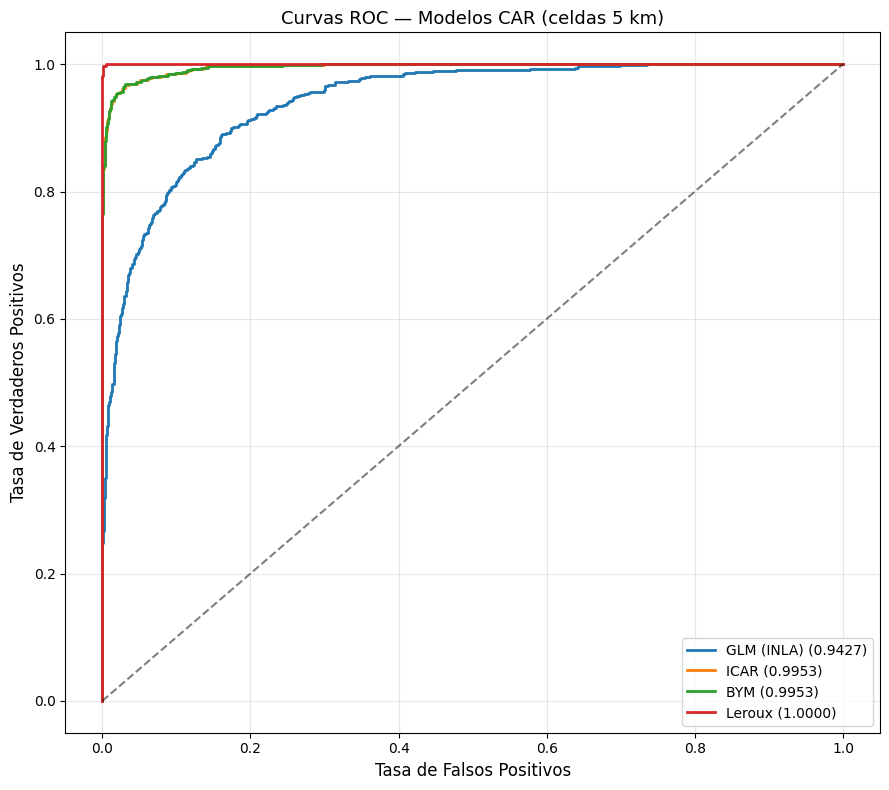

In [9]:
fig, ax = plt.subplots(figsize=(9, 8))
for res in resultados_car:
    fpr, tpr, _ = roc_curve(y_obs, res['prob'])
    ax.plot(fpr, tpr, label=f'{res["nombre"]} ({res["auc"]:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curvas ROC — Modelos CAR (celdas 5 km)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '02_curvas_roc_car.png'), dpi=150, bbox_inches='tight')
plt.show()

### Matrices de confusión — Modelos CAR

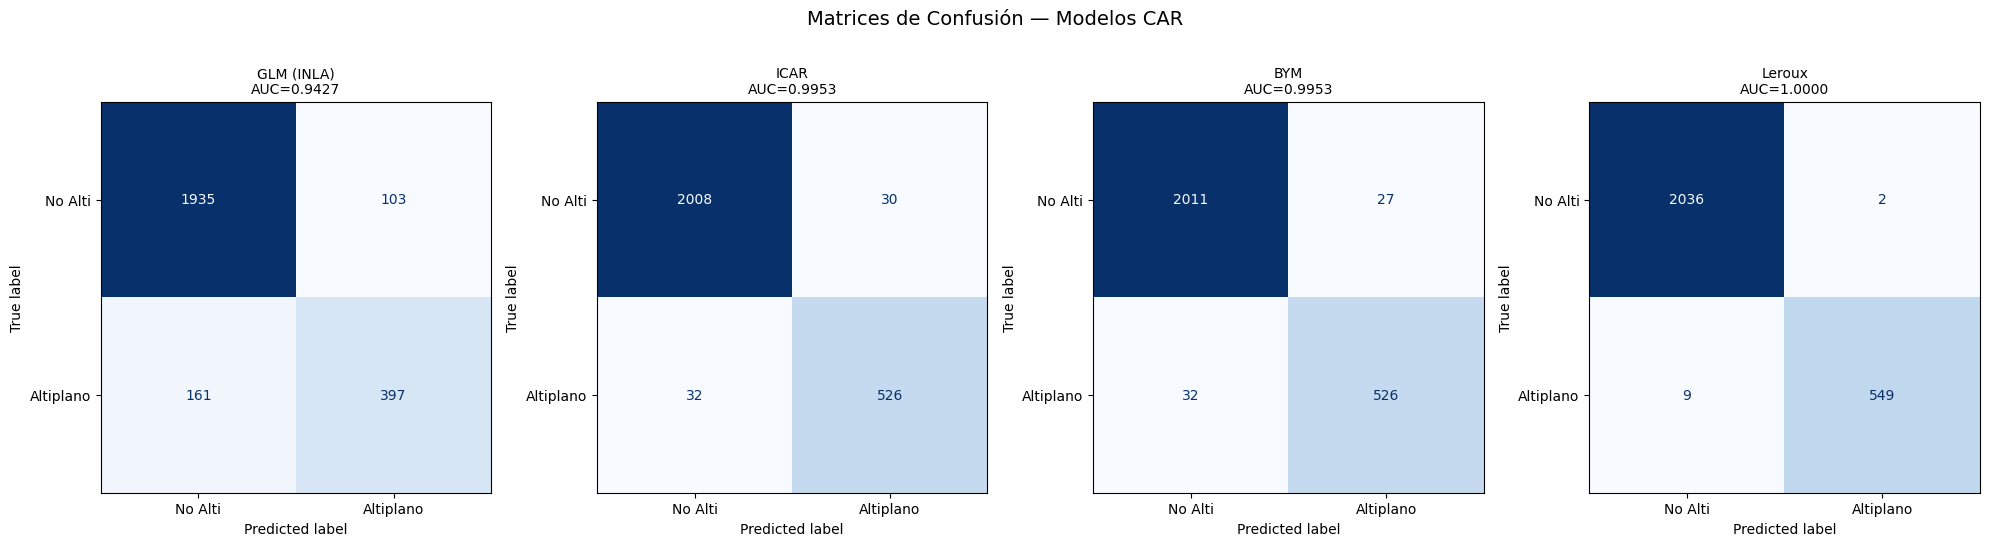

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, res in enumerate(resultados_car):
    pred_class = (res['prob'] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_obs, pred_class,
        display_labels=['No Alti', 'Altiplano'],
        ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{res["nombre"]}\nAUC={res["auc"]:.4f}', fontsize=10)

plt.suptitle('Matrices de Confusión — Modelos CAR', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '03_matrices_confusion_car.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Mapas de efectos espaciales y predicción

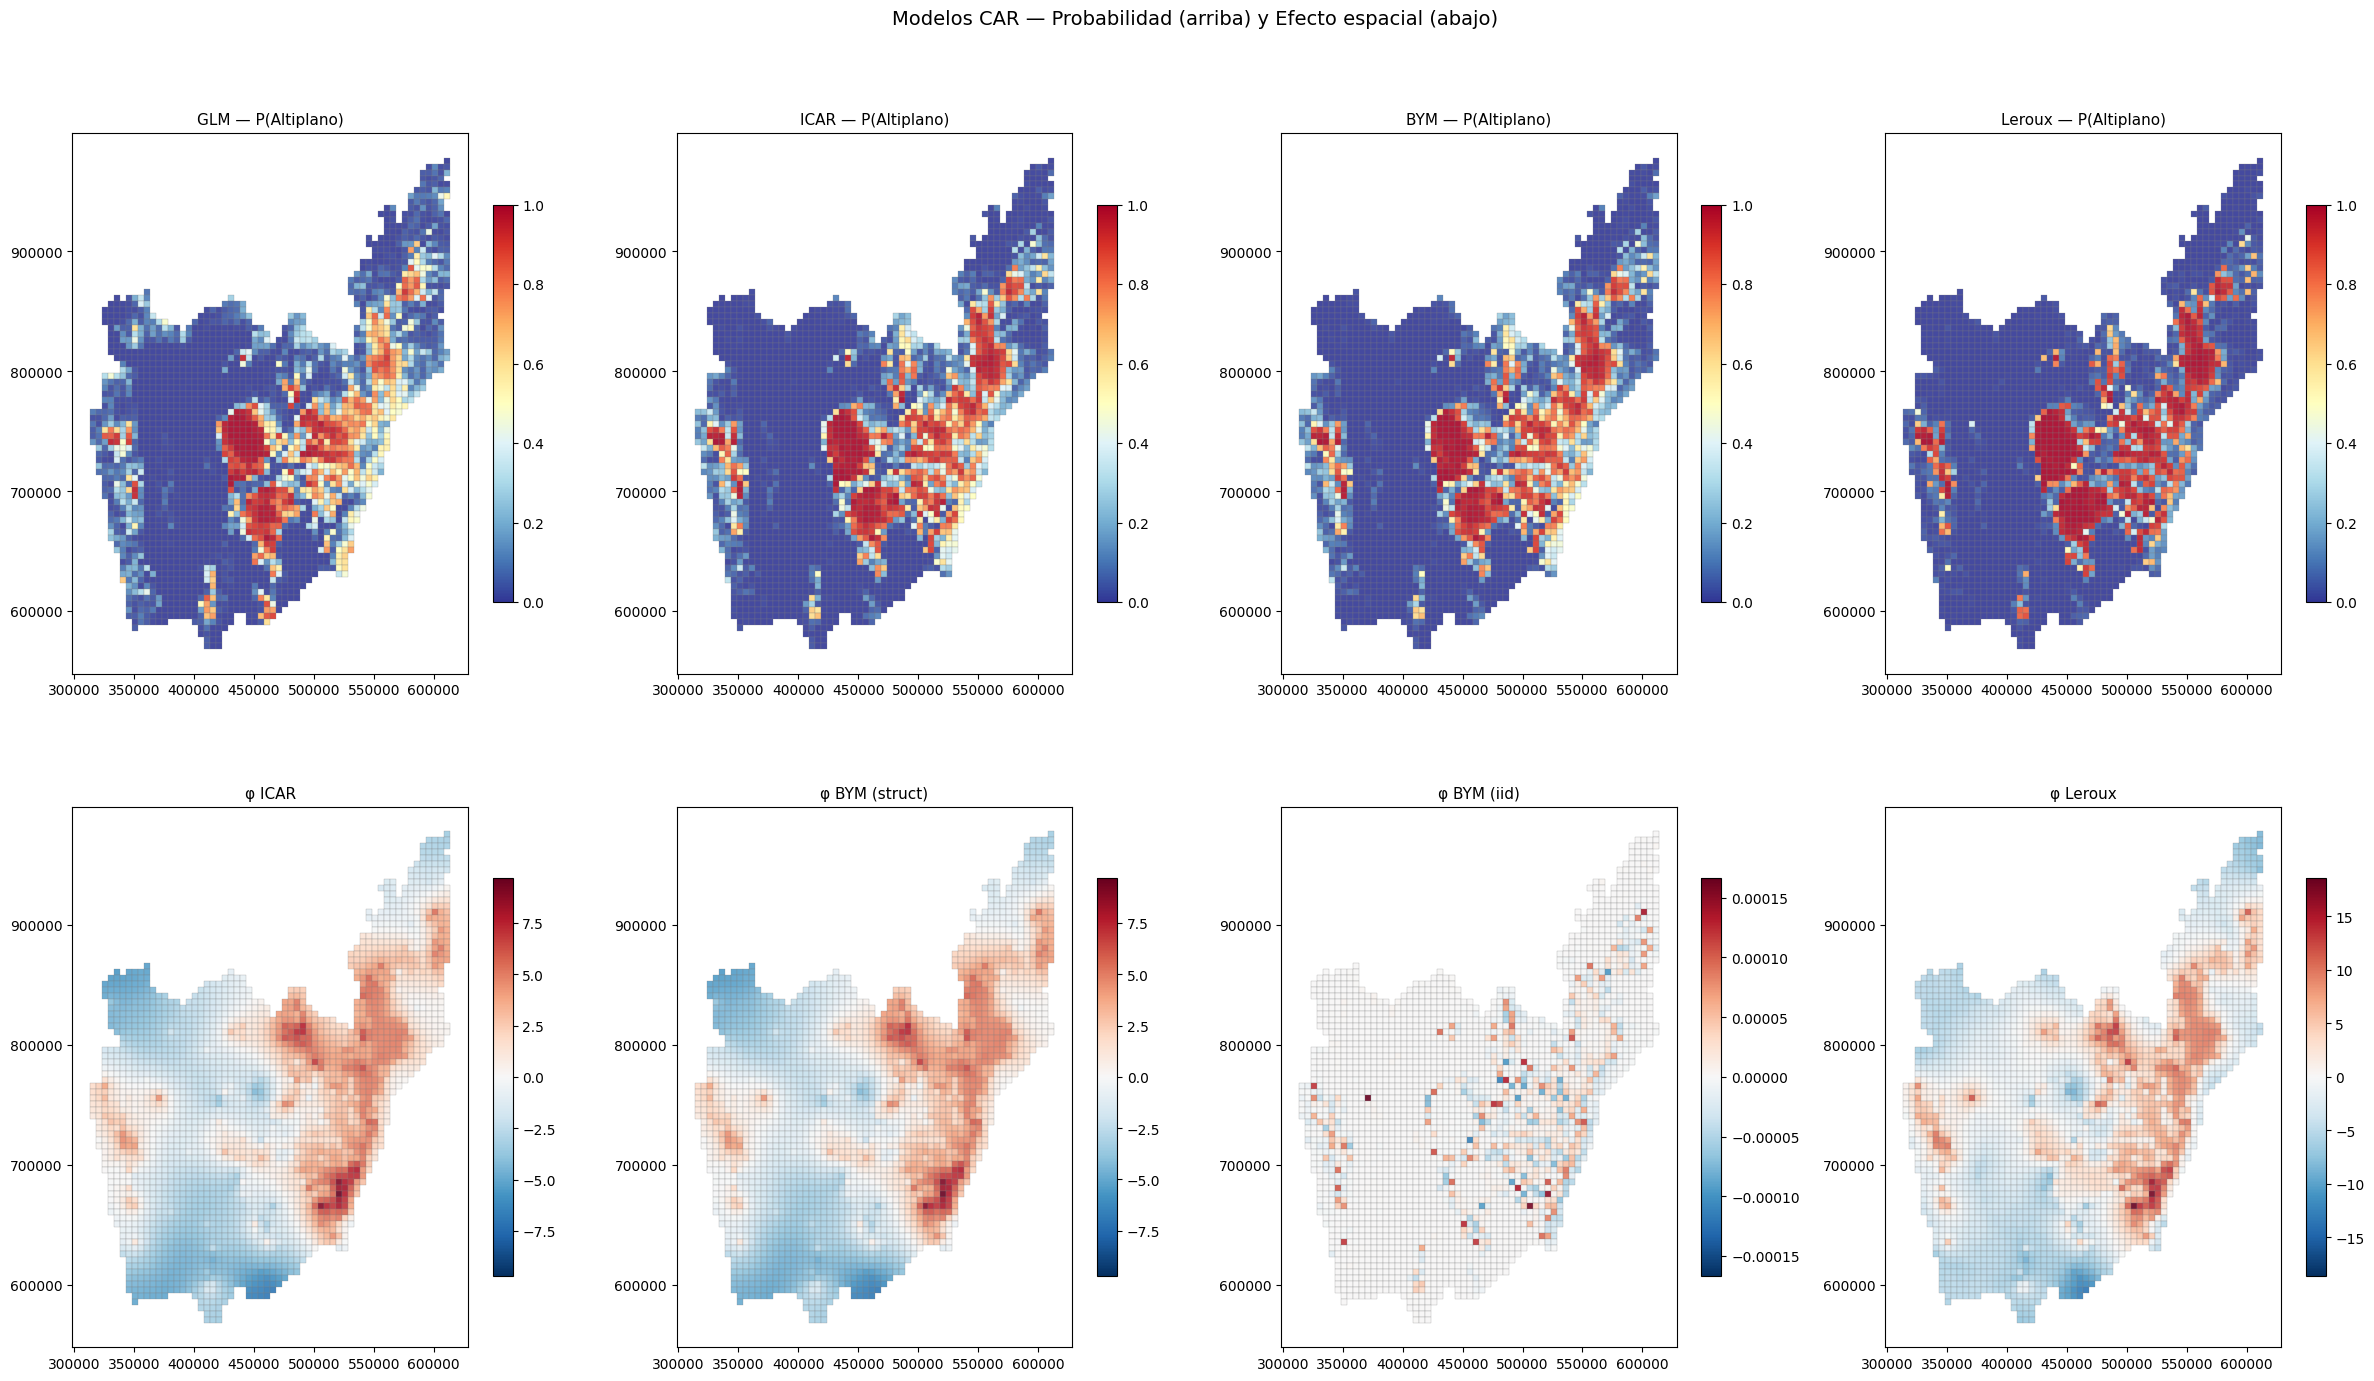

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(24, 14))

# Row 1: Predicted probabilities
for i, (col, nombre) in enumerate([('prob_glm', 'GLM'), ('prob_icar', 'ICAR'),
                                    ('prob_bym', 'BYM'), ('prob_leroux', 'Leroux')]):
    ax = axes[0, i]
    gdf_tmp = gdf.copy()
    gdf_tmp['prob'] = probs[col].values
    gdf_tmp.plot(column='prob', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
                 linewidth=0.2, alpha=0.9, vmin=0, vmax=1, legend=True,
                 legend_kwds={'shrink': 0.6})
    ax.set_title(f'{nombre} — P(Altiplano)', fontsize=11)
    ax.set_aspect('equal')

# Row 2: Spatial effects (phi)
phi_cols = ['phi_icar', 'phi_bym_struct', 'phi_bym_iid', 'phi_leroux']
phi_names = ['φ ICAR', 'φ BYM (struct)', 'φ BYM (iid)', 'φ Leroux']
for i, (col, nombre) in enumerate(zip(phi_cols, phi_names)):
    ax = axes[1, i]
    gdf_tmp = gdf.copy()
    gdf_tmp['phi'] = spatial[col].values
    vmax = max(abs(gdf_tmp['phi'].min()), abs(gdf_tmp['phi'].max()))
    gdf_tmp.plot(column='phi', ax=ax, cmap='RdBu_r', edgecolor='gray',
                 linewidth=0.2, alpha=0.9, vmin=-vmax, vmax=vmax,
                 legend=True, legend_kwds={'shrink': 0.6})
    ax.set_title(f'{nombre}', fontsize=11)
    ax.set_aspect('equal')

plt.suptitle('Modelos CAR — Probabilidad (arriba) y Efecto espacial (abajo)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '04_mapas_prob_phi.png'), dpi=150, bbox_inches='tight')
plt.show()

### Mapas con plantilla cartográfica — Mejor modelo CAR

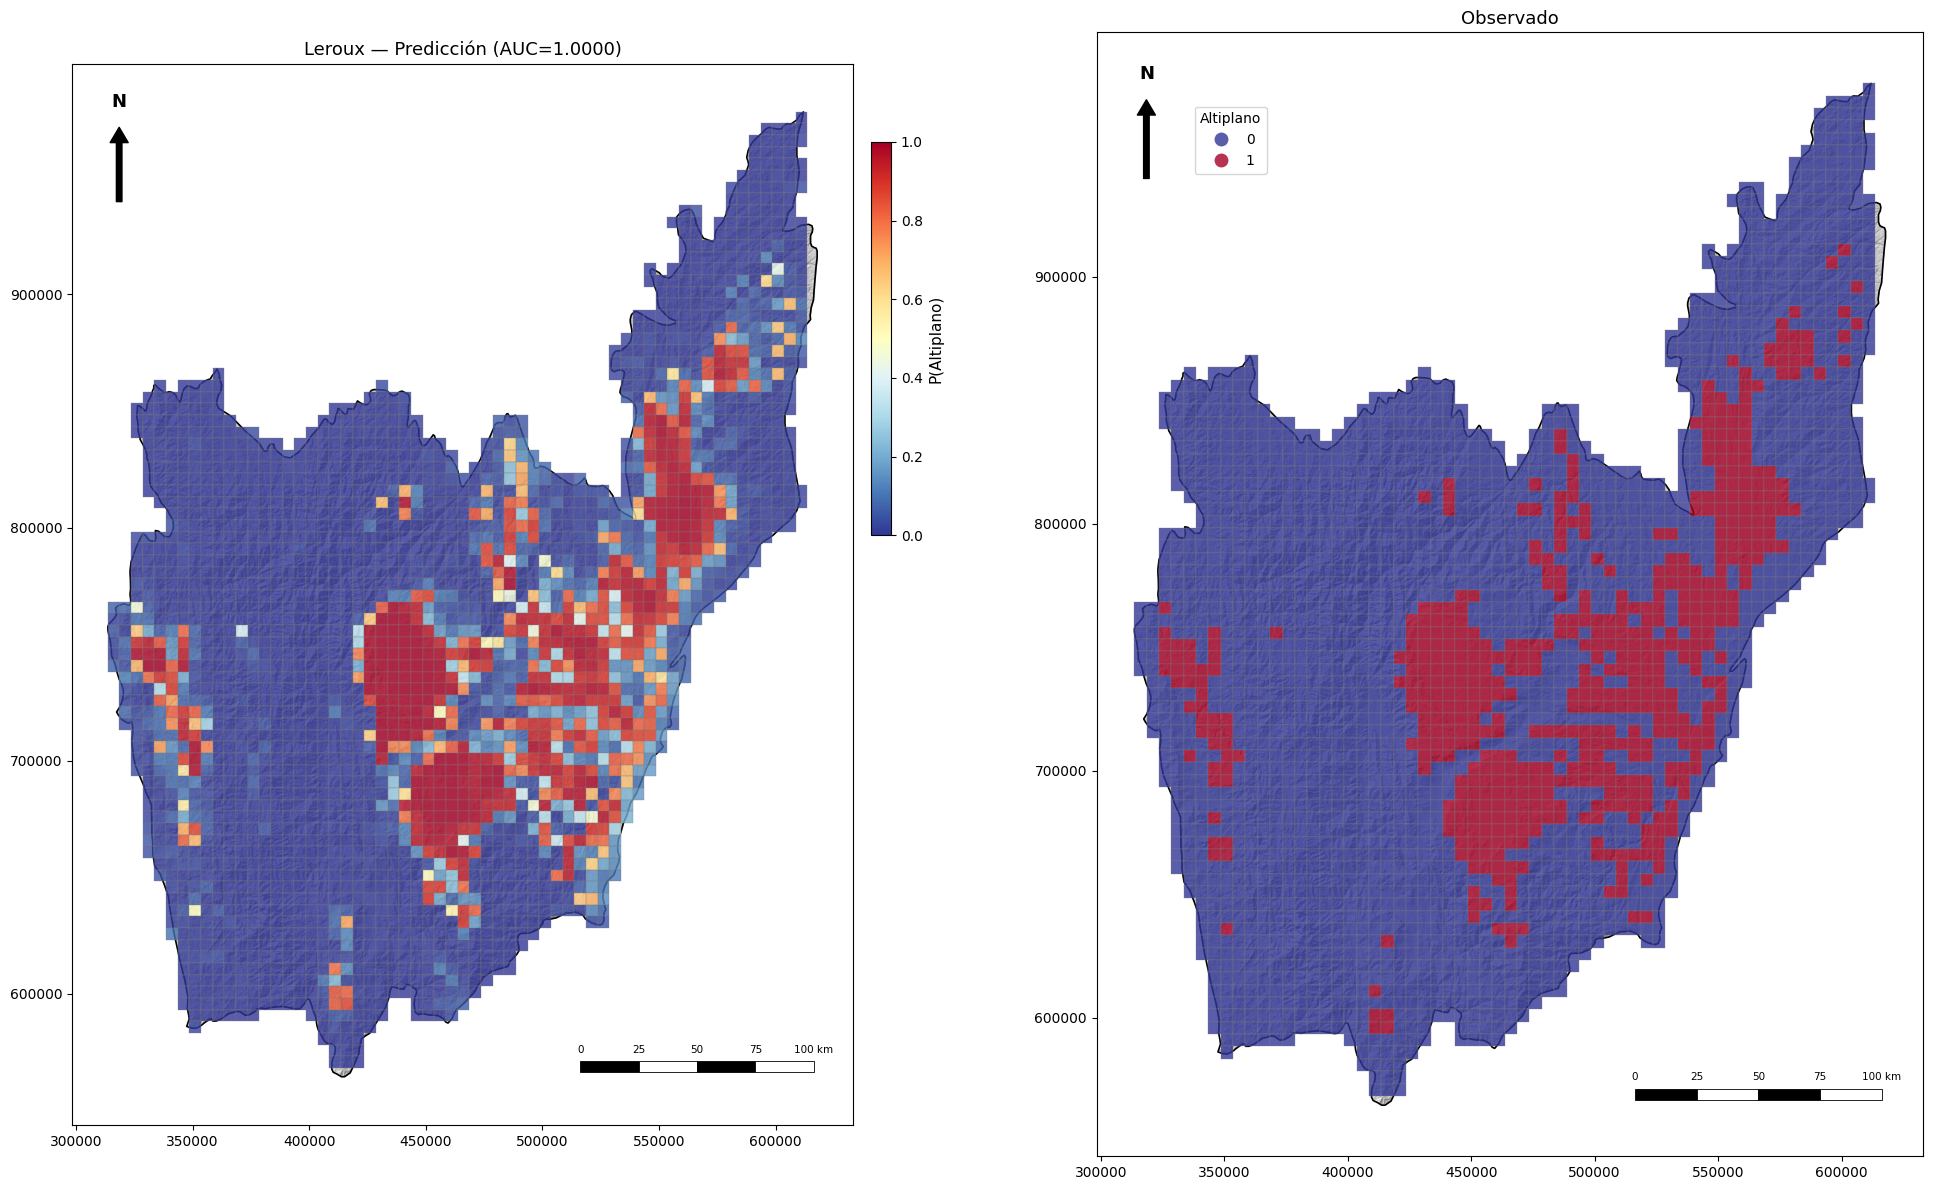

In [12]:
from plantilla_mapas import aplicar_plantilla_mapa, posicionar_leyenda

best_car = max(resultados_car, key=lambda x: x['auc'])
gdf_plot = gdf.copy()
gdf_plot['prob_best'] = best_car['prob']

fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# Map 1: predicted probability (continuous → manual colorbar)
ax = axes[0]
ancla = aplicar_plantilla_mapa(ax)
gdf_plot.plot(column='prob_best', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
              linewidth=0.3, alpha=0.8, vmin=0, vmax=1, zorder=5,
              legend=False)
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(0, 1))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.35, aspect=20, pad=0.02,
                    anchor=(0.0, 0.85))
cbar.set_label('P(Altiplano)', fontsize=11)
ax.set_title(f'{best_car["nombre"]} — Predicción (AUC={best_car["auc"]:.4f})', fontsize=13)

# Map 2: observed (categorical → posicionar_leyenda is fine)
ax = axes[1]
ancla = aplicar_plantilla_mapa(ax)
gdf.plot(column='y', ax=ax, cmap='RdYlBu_r', edgecolor='gray',
         linewidth=0.3, alpha=0.8, zorder=5, categorical=True,
         legend=True,
         legend_kwds=posicionar_leyenda(ax, ancla, titulo='Altiplano'))
ax.set_title('Observado', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, '05_mapa_plantilla_car.png'),
            dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(IMG_DIR, '05_mapa_plantilla_car.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 10. Exportación de resultados

In [13]:
gdf_out = gdf[['y', 'altitud', 'pendiente', 'relieve', 'region', 'geometry']].copy()

for col, cname in [('prob_glm', 'prob_glm'), ('prob_icar', 'prob_icar'),
                    ('prob_bym', 'prob_bym'), ('prob_leroux', 'prob_ler')]:
    gdf_out[cname] = probs[col].values

for col in ['phi_icar', 'phi_bym_struct', 'phi_bym_iid', 'phi_leroux']:
    short = col.replace('phi_bym_struct', 'phi_bym_s').replace('phi_bym_iid', 'phi_bym_i')
    gdf_out[short] = spatial[col].values

best_car_name = max(resultados_car, key=lambda x: x['auc'])
gdf_out['pred_best'] = (best_car_name['prob'] >= 0.5).astype(int)

out_path = os.path.join(BASE, 'Resultados', 'car_inla_comparacion_v2.gpkg')
gdf_out.to_file(out_path, driver='GPKG')
print(f'GeoPackage exportado: {out_path}')
print(f'  Registros: {len(gdf_out):,}')
print(f'  Columnas: {list(gdf_out.columns)}')

GeoPackage exportado: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\car_inla_comparacion_v2.gpkg
  Registros: 2,596
  Columnas: ['y', 'altitud', 'pendiente', 'relieve', 'region', 'geometry', 'prob_glm', 'prob_icar', 'prob_bym', 'prob_ler', 'phi_icar', 'phi_bym_s', 'phi_bym_i', 'phi_leroux', 'pred_best']


In [14]:
print('\n' + '=' * 80)
print('  RESUMEN FINAL — Modelos CAR (Sección 3)')
print('=' * 80)

df_car_final = pd.DataFrame(resultados_car)
cols = ['nombre', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'dic', 'waic']
print(df_car_final[cols].to_string(index=False,
    float_format=lambda x: f'{x:.4f}' if abs(x) < 10 else f'{x:.1f}', na_rep='—'))

best = df_car_final.loc[df_car_final['auc'].idxmax()]
print(f'\nMejor CAR por AUC: {best["nombre"]} (AUC={best["auc"]:.4f})')
best_dic = df_car_final.loc[df_car_final['dic'].idxmin()]
print(f'Mejor CAR por DIC: {best_dic["nombre"]} (DIC={best_dic["dic"]:.1f})')

print(f'\nArchivos generados:')
for d in [RES_DIR, IO_DIR]:
    for f in sorted(os.listdir(d)):
        if not f.startswith('_') and not f.startswith('.'):
            fpath = os.path.join(d, f)
            if os.path.isfile(fpath):
                sz = os.path.getsize(fpath)
                print(f'  {os.path.basename(d)}/{f} ({sz/1024:.0f} KB)')


  RESUMEN FINAL — Modelos CAR (Sección 3)
    nombre    auc  accuracy     f1  precision  recall    dic   waic
GLM (INLA) 0.9427    0.8983 0.7505     0.7940  0.7115 1270.3 1271.1
      ICAR 0.9953    0.9761 0.9443     0.9460  0.9427 1340.5 2348.6
       BYM 0.9953    0.9773 0.9469     0.9512  0.9427 1188.0 1293.0
    Leroux 1.0000    0.9958 0.9901     0.9964  0.9839  701.4  674.9

Mejor CAR por AUC: Leroux (AUC=1.0000)
Mejor CAR por DIC: Leroux (DIC=701.4)

Archivos generados:
  11_CAR_INLA_comparacion_v2/02_curvas_roc_car.png (81 KB)
  11_CAR_INLA_comparacion_v2/03_matrices_confusion_car.png (56 KB)
  11_CAR_INLA_comparacion_v2/04_mapas_prob_phi.png (493 KB)
  11_CAR_INLA_comparacion_v2/05_mapa_plantilla_car.png (2286 KB)
  11_CAR_INLA_comparacion_v2/metricas_todos_seccion3.csv (2 KB)
  11_CAR_INLA_io/adj_inla.txt (64 KB)
  11_CAR_INLA_io/car_coeficientes_inla.csv (2 KB)
  11_CAR_INLA_io/car_efectos_espaciales.csv (191 KB)
  11_CAR_INLA_io/car_hiperparametros.csv (0 KB)
  11_CAR_INLA_